In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

connect all files 

In [2]:
products = pd.read_csv("Data_files/Products.csv")
Product_cat = pd.read_csv("Data_files/ProductCategories.csv")
Store_D = pd.read_csv("Data_files/StoreDetail.csv")
Store_S = pd.read_csv("Data_files/StoreSales.csv")
Customer = pd.read_csv("Data_files/customer_list_limpio.csv")

In [3]:
# putting togeth sales with store details
sales_merged = Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")



# Filtering, Sorting & Exploration

1. Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [12]:
# change transaction date colmn into date format
sales_merged["Transaction Date"] =pd.to_datetime(sales_merged["Transaction Date"])

# filter for jan 2024
jan_2024 = sales_merged[
    (sales_merged["Transaction Date"].dt.year == 2024) &
    (sales_merged["Transaction Date"].dt.month ==1)]

#sort transactions from highest to lowest sale amount
jan_2024 = jan_2024.sort_values(by="Sale Amount",ascending=False)

# show jan 2024 transactions 
jan_2024.style.hide(axis="index")
# =======================================
# show only transaction with sale amounts more than 500
high_amount = jan_2024[
    jan_2024["Sale Amount"] > 500]

# show amounts more than 500
high_amount.style.hide(axis="index")

Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
2024-01-01 00:00:00,726,nan,105341-IT,1763.700000,Orlando,Florida,Lana Ilana,South,Andy Gisselquist
2024-01-31 00:00:00,822,nan,105341-IT,1763.700000,Orono,Maine,Erbayne Middleton,Northeast,Michael Jarvis
2024-01-18 00:00:00,736,nan,105341-IT,1763.700000,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-10 00:00:00,823,337.000000,105341-IT,1763.700000,South Portland,Maine,Erbayne Middleton,Northeast,Michael Jarvis
2024-01-27 00:00:00,701,nan,105341-IT,1763.700000,Aurora,Colorado,Jim Heck,West,Cassie Chambers
2024-01-09 00:00:00,872,nan,105341-IT,1763.700000,Waterbury,Connecticut,Ellen Lemon,East,Ana Jilani
2024-01-09 00:00:00,731,nan,105341-IT,1763.700000,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-27 00:00:00,736,nan,105341-IT,1763.700000,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-31 00:00:00,729,nan,105326-IT,1717.700000,Tampa,Florida,Lana Ilana,South,Andy Gisselquist
2024-01-10 00:00:00,705,nan,105325-IT,1717.700000,Denver,Colorado,Jim Heck,West,Cassie Chambers


2. Find all products whose product number begins with 10525. What category and subcategory do they
belong

In [5]:
# Merge products table with product category table
product_data = products.merge(
    Product_cat,
    on=["CategoryID", "SubcategoryID"],
    how="left")

# Filter products where product number starts with 10525
products_10525 = product_data[
    product_data["Prod Num"].astype(str).str.startswith("10525")]

# Select relevant columns
products_10525 = products_10525[
    [
        "Prod Num",
        "Product",
        "Category",
        "Subcategory"]]

# Remove duplicate rows
products_10525 = products_10525.drop_duplicates()

# Display results
products_10525.style.hide(axis="index")

Prod Num,Product,Category,Subcategory
105250-IT,Realme Pad,Technology & Accessories,Tablets
105251-IT,Lenovo Tab P12 Pro,Technology & Accessories,Tablets
105252-IT,Microsoft Surface Pro 9,Technology & Accessories,Tablets
105253-IT,"Apple iPad Pro (12.9-inch, M2)",Technology & Accessories,Tablets
105254-IT,Chuwi HiPad Max,Technology & Accessories,Tablets
105255-IT,Lenovo Yoga Smart Tab,Technology & Accessories,Tablets
105256-IT,ASUS Vivobook 13 Slate OLED,Technology & Accessories,Tablets
105257-IT,Samsung Galaxy Tab S9 Ultra,Technology & Accessories,Tablets
105258-IT,Apple iPad Air (10.9-inch),Technology & Accessories,Tablets
105259-IT,Teclast T40 Pro,Technology & Accessories,Tablets


3. Which stores in your assigned territories had at least one transaction with a sale amount over
$1,000? How many such transactions did each store have?

In [13]:
# Filter only Maine and Maryland territories
territory_sales = sales_merged[
    sales_merged["State"].isin(["Maine", "Maryland"])]

# Keep only transactions greater than $1,000
high_value_sales = territory_sales[
    territory_sales["Sale Amount"] > 1000]

# Group by store and count the number of transactions
store_transaction_counts = high_value_sales.groupby(
    ["State", "Store ID", "Store Location"]
)["Sale Amount"].count().reset_index()

# Rename count column for easier understanding
store_transaction_counts = store_transaction_counts.rename(
    columns={"Sale Amount": "Transactions more than $1,000"})

# Sort stores from highest transaction count to lowest
store_transaction_counts = store_transaction_counts.sort_values(
    by="Transactions more than $1,000",
    ascending=False)

# show results
store_transaction_counts.style.hide(axis="index")

State,Store ID,Store Location,"Transactions more than $1,000"
Maryland,736,North Harford,2241
Maryland,734,Germantown,153
Maine,823,South Portland,97
Maine,820,Kennebunkport,93
Maine,818,Bangor,93
Maryland,737,Parkville,91
Maryland,739,Ridgely,90
Maryland,733,Baltimore,89
Maryland,735,Howard,86
Maine,822,Orono,85


# Aggregation & NumPy

# What is the total sales revenue across all in-store transactions in the dataset? What is the average transaction amount? What is the standard deviation?

In [7]:
# Total sale revenues
total_revenue = Store_S["Sale Amount"].sum()

#calculate avg transaction amount using mean
avg_transactions = Store_S["Sale Amount"].mean()

#finding standard deviation of transaction amounts
transaction_dev = Store_S["Sale Amount"].std()

print("Total Sale Revenue: $", round(total_revenue,2))
print("Average Transaction Amount: $", round(avg_transactions,2))
print("Standard Deviation: $", round(transaction_dev,2))

Total Sale Revenue: $ 45370048.85
Average Transaction Amount: $ 135.38
Standard Deviation: $ 279.72


# Which stores had total revenue above the average store revenue across the full dataset? (Hint: use np.mean().

In [14]:
# total revenue for each store
store_revenue = sales_merged.groupby(
    ["Store ID","Store Location","State"])["Sale Amount"].sum().reset_index()

# avg store revenues
avg_store_revenue = np.mean(store_revenue["Sale Amount"])

# pulling stores with revenue above the average
above_average_stores = store_revenue[store_revenue["Sale Amount"] > avg_store_revenue]

# print show the avg store revenue using np.mean 
print(
    "Average Store Revenue: $",
    round(avg_store_revenue, 2)
)

above_average_stores



Average Store Revenue: $ 408739.18


,Store ID,Store Location,State,Sale Amount
4,705,Denver,Colorado,917471.53
8,709,Greeley,Colorado,640368.11
23,724,Miami,Florida,618846.25
27,728,Tallahassee,Florida,541670.66
33,734,Germantown,Maryland,584675.92
35,736,North Harford,Maryland,8708119.00
55,817,Worcester,Massachusetts,602183.44
73,835,Newark,New Jersey,623163.53
76,838,Trenton,New Jersey,597565.68
85,847,Rochester,New York,607148.21


# What is the total revenue for each product category across all territories, sorted from highest to lowest? Which category has the most individual transactions

In [9]:
# join products table with category table
product_data = products.merge(
    Product_cat,
    on=["CategoryID","SubcategoryID"],
    how="left")

# now join sales table with product and category 
sales_products = Store_S.merge(
    product_data,
    on="Prod Num",
    how="left")

# calculate total revenue and transaction counts for each category
category_summary = sales_products.groupby("Category").agg({"Sale Amount":["sum","count"]}).reset_index()

# since column name are remade internally we need to rename them for no confusion
category_summary.columns = [
    "Category",
    "Total Revenue",
    "Transaction Count"]

# sort from highest to lowest revenue
category_summary = category_summary.sort_values(by="Total Revenue",ascending=False)

category_summary

,Category,Total Revenue,Transaction Count
4,Technology & Accessories,31891406.58,68344
5,Textbooks,7961357.21,45924
0,Apparel and Merchandise,2043382.60,63346
1,Art Supplies,1938358.84,62028
2,Books (General),1070718.51,35196
3,Stationery and Supplies,702088.52,69176


# Across the full dataset, what are the top 10 best-selling individual products by total revenue?

In [15]:
# total revenue for each product
top_product = sales_products.groupby(["Prod Num","Product"])["Sale Amount"].sum().reset_index()

# sort products from highest revenue to lowest
top_product = top_product.sort_values(by="Sale Amount",ascending=False)

# show top 10 
top_product.head(10)

,Prod Num,Product,Sale Amount
93,105341-IT,MSI Creator Z16,1199316.00
77,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1082151.00
78,105326-IT,"Apple MacBook Air (M2, 13-inch)",1003136.80
89,105337-IT,HP Pavilion 14,913919.76
85,105333-IT,ASUS VivoBook S15,900524.00
86,105334-IT,Samsung Galaxy Book Pro,890257.12
76,105324-IT,Lenovo IdeaPad Flex 5,877535.40
82,105330-IT,LG Gram 17,876792.28
84,105332-IT,HP Spectre x360,874421.04
83,105331-IT,Acer Chromebook Spin 713,872358.20


# Bar chart analysis

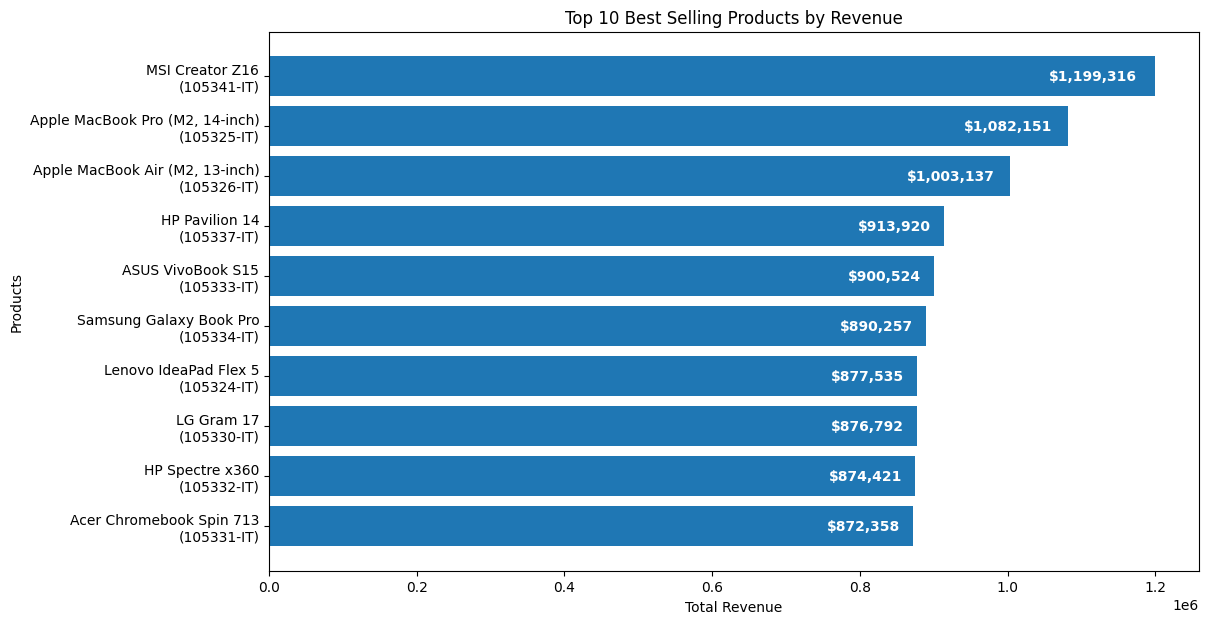

In [17]:
# only 10 products 
top_10_products = top_product.head(10)

# clean labels
top_10_products["Product Label"]=(
    top_10_products["Product"] + "\n(" +
    top_10_products["Prod Num"].astype(str) + ")")

#create figure
plt.figure(figsize=(12,7))

# Create horizontal chart
bars = plt.barh(
    top_10_products["Product Label"],
    top_10_products["Sale Amount"])

# put highest revenue on top
plt.gca().invert_yaxis()

# add title and labels
plt.title("Top 10 Best Selling Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Products")

# Add revenue inside bars
for bar in bars:
    width = bar.get_width()

    plt.text(
        width - (width * 0.02),  # just a little inside bar tip
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        ha="right",
        color="white",
        fontweight="bold")

# Merging and Grouping

8.) For each transaction in your territories, display the transaction date, sale amount, city, state, and
territory manager. (Requires merging StoreSales with StoreDetail.

In [ ]:
# join sales transactions and store details
sales_merged= Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")

# keep maine and maryland
territory_transactions = sales_merged[sales_merged["State"].isin(["Maine","Maryland"])]

# show columns
territory_transactions[["Transaction Date",
                        "Sale Amount",
                        "Store Location",
                        "State",
                        "Territory Manager"]]
territory_transactions.head()

9,)What is total revenue by region across the full dataset? Which region generates the most revenue?
(Requires merging with StoreDetail and grouping by Region.)


In [ ]:
# calculate total revenue by region
region_revenue = sales_merged.groupby(
    "Region")["Sale Amount"].sum().reset_index()

# sort from highest revenue to lowest
region_revenue = region_revenue.sort_values(by="Sale Amount",ascending=False)
region_revenue

10. For each product subcategory in your territories, calculate the total revenue and number of
transactions. Which subcategories are driving the most revenue? (Requires merging StoreSales →
Products → ProductCategories.)

In [ ]:
# keep only Maine and Maryland 
territory_sales = sales_merged[sales_merged["State"].isin(["Maine","Maryland"])]

#join territory sales with product and category
sales_products = territory_sales.merge(
    product_data,
    on="Prod Num",
    how="left")

# revenue and transaction counts by subcategory
subcategory_summary =sales_products.groupby(
    "Subcategory").agg({"Sale Amount":["sum","count"]}).reset_index()

# change column names
subcategory_summary.columns = [
    "Subcategory",
    "Total Revenue",
    "Transaction Count"]

subcategory_summary = subcategory_summary.sort_values(by="Total Revenue",ascending=False)

subcategory_summary.head()


11. Using the customer list, identify all rewards members who made purchases in your territories. What
is the average transaction value for rewards members compared to non-rewards customers?
(Requires merging StoreSales with customer_list on RewardsID = cust_id.)

In [22]:
customer_sales = territory_sales.merge(
    Customer,
    left_on="RewardsID",
    right_on="cust_id",
    how="left")

# Calculate total spend and transaction count for each  member
top_rewards_members = customer_sales.groupby(["cust_id", "name"]).agg({"Sale Amount": ["sum", "count"]}).reset_index()

# Rename columns
top_rewards_members.columns = [
    "Customer ID",
    "Customer Name",
    "Total Spend",
    "Transaction Count"]

# Sort by total spend and return top 10
top_rewards_members = top_rewards_members.sort_values(
    by="Total Spend",
    ascending=False)

top_rewards_members.head(10)

,Customer ID,Customer Name,Total Spend,Transaction Count
98,99.0,Trent Lane,8635.10,25
179,180.0,Cole Brown,7762.23,30
88,89.0,Karen Walker,7635.37,26
354,355.0,Donna Hayward,7087.17,25
466,467.0,Avon Barksdale,6393.67,31
361,362.0,Wednesday Addams,6376.52,21
393,394.0,Blanche Devereaux,6250.14,25
96,97.0,Jane Lane,6164.29,28
74,75.0,Magnitude,6049.22,22
6,7.0,Gunther,5936.20,22


12.) Who are the top 10 rewards members by total spend across the full dataset? How many
transactions does each have?

In [23]:
# find total spent and transaction count 
top_rewards_members = customer_sales.groupby(["cust_id","name"]).agg({"Sale Amount":["sum","count"]}).reset_index()

# change column names
top_rewards_members.columns =[
    "Customer ID",
    "Customer Name",
    "Total Spend",
    "Transaction Count"]

# sorty by total spend and show top 10 members
top_rewards_members = top_rewards_members.sort_values(by="Total Spend",ascending=False)
top_rewards_members.head(10)

,Customer ID,Customer Name,Total Spend,Transaction Count
98,99.0,Trent Lane,8635.10,25
179,180.0,Cole Brown,7762.23,30
88,89.0,Karen Walker,7635.37,26
354,355.0,Donna Hayward,7087.17,25
466,467.0,Avon Barksdale,6393.67,31
361,362.0,Wednesday Addams,6376.52,21
393,394.0,Blanche Devereaux,6250.14,25
96,97.0,Jane Lane,6164.29,28
74,75.0,Magnitude,6049.22,22
6,7.0,Gunther,5936.20,22


# Advanced / Stretch

13. Compare year-over-year revenue for your territories. Is each territory trending up or down between
years?

In [24]:
# keep maine and maryland
territory_sales = sales_merged[sales_merged["State"].isin(["Maine","Maryland"])]

#get year from transaction date
territory_sales["Year"] = pd.to_datetime(territory_sales["Transaction Date"]).dt.year

# total revenue by state and year
yearly_revenue = territory_sales.groupby(["State","Year"])["Sale Amount"].sum().reset_index()
yearly_revenue

,State,Year,Sale Amount
0,Maine,2022,279074.94
1,Maine,2023,450814.79
2,Maine,2024,452377.73
3,Maine,2025,694982.29
4,Maryland,2022,2409967.70
5,Maryland,2023,2813693.20
6,Maryland,2024,2821691.59
7,Maryland,2025,3406262.60


14. Identify the single best month and single worst month for each of your territories over the full data
period

In [28]:
# make year and month column
territory_sales["Year_Month"] = pd.to_datetime(territory_sales["Transaction Date"]).dt.to_period("M")

# montly revenue by territory
monthly_revenue = territory_sales.groupby(["State","Year_Month"])["Sale Amount"].sum().reset_index()

# best month for territories
best_months = monthly_revenue.loc[monthly_revenue.groupby("State")["Sale Amount"].idxmax()]

# worst month for each territory
worst_months = monthly_revenue.loc[monthly_revenue.groupby("State")["Sale Amount"].idxmin()]

best_months
worst_months

,State,Year_Month,Sale Amount
0,Maine,2022-01,15700.31
56,Maryland,2022-09,158952.74


15. Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line
alongside the monthly revenue chart. Is your territory trending up or down overall?

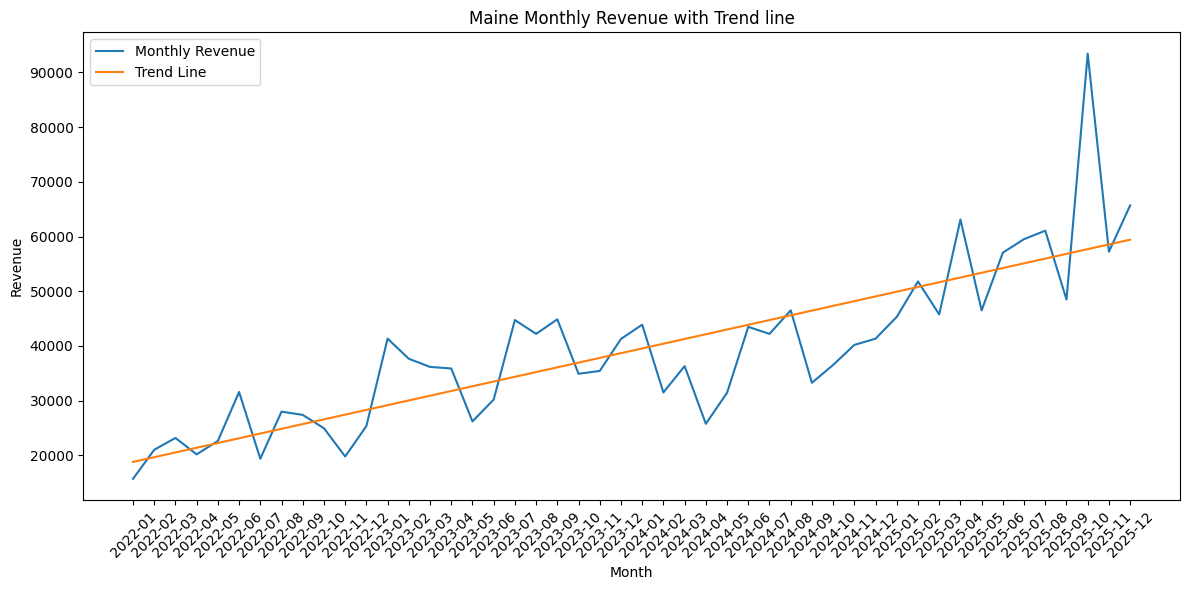

np.float64(864.6406258141554)

In [37]:
# show maine
maine_revenue = monthly_revenue[monthly_revenue["State"] == "Maine"].copy()

# create month numbers for regression
maine_revenue["Month_Number"] = range(len(maine_revenue))

# x and y variables
x = maine_revenue[["Month_Number"]]
y = maine_revenue["Sale Amount"]

#linear regression model
model = LinearRegression()
model.fit(x,y)

# make trend lines value
maine_revenue["Trend Line"] = model.predict(X)

# plot monthly rev and trend line
plt.figure(figsize=(12,6))

plt.plot(
    maine_revenue["Year_Month"].astype(str),
    maine_revenue["Sale Amount"],
    label="Monthly Revenue")

plt.plot(maine_revenue["Year_Month"].astype(str),
         maine_revenue["Trend Line"],
         label="Trend Line")


plt.title("Maine Monthly Revenue with Trend line")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

model.coef_[0]

Based off the mode. my territory for maine is trending upward over the period analyzed.The line has a positive slope of 864.64